<div style="background: linear-gradient(135deg, #0f6e56 0%, #1d9e75 100%); padding: 40px; border-radius: 12px; text-align: center; color: white;">
  <h1 style="font-size: 2.5em; margin: 0; letter-spacing: 2px;">💧 AquaVision</h1>
  <h3 style="font-weight: 300; margin: 8px 0 0;">Water Quality Index Prediction System</h3>
  <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 16px 0;">
  <p style="margin: 0; font-size: 0.95em; opacity: 0.85;">Brainybeam Info-Tech PVT LTD &nbsp;|&nbsp; Data Science & Machine Learning Internship</p>
</div>

---

## 📋 Notebook Information

| Field | Details |
|---|---|
| **Notebook** | 01 — Data Collection & Loading |
| **Phase** | Phase 1 of 5 |
| **Author** | [Your Name] |
| **Company** | Brainybeam Info-Tech PVT LTD |
| **Date** | March 2026 |
| **Python Version** | 3.x |
| **Status** | ✅ Complete |

---

## 📝 Abstract

Water quality assessment is a critical component of environmental monitoring and public health management. The **Water Quality Index (WQI)** is a widely used composite score that aggregates multiple physicochemical parameters into a single value, allowing stakeholders to quickly assess the suitability of water for drinking, agriculture, or aquatic life.

This notebook marks the beginning of the **AquaVision** project — an end-to-end data science pipeline designed to evaluate and predict WQI scores using machine learning. In this first phase, we focus on:

- Setting up the analytical environment with all necessary libraries
- Loading and inspecting the water quality dataset
- Performing an initial structural assessment of the data
- Identifying missing values and data quality issues
- Documenting observations to guide subsequent analysis phases

The dataset used contains **3,276 water samples** with **9 physicochemical parameters** including pH, hardness, dissolved solids, chloramines, sulfate, conductivity, organic carbon, trihalomethanes, and turbidity, along with a binary potability label.

> **Goal of this notebook:** Understand the raw data thoroughly before any transformation or modeling takes place.

---

## 📚 Table of Contents

1. [Library Imports](#1-library-imports)
2. [Project Configuration](#2-project-configuration)
3. [Dataset Loading](#3-dataset-loading)
4. [Initial Data Inspection](#4-initial-data-inspection)
5. [Statistical Summary](#5-statistical-summary)
6. [Missing Value Analysis](#6-missing-value-analysis)
7. [Data Types & Memory Usage](#7-data-types--memory-usage)
8. [Key Observations & Next Steps](#8-key-observations--next-steps)

---

## 1. Library Imports

### 📖 Why this step?

Before any data work begins, we import all required libraries. This is a professional best practice — keeping all imports at the top of the notebook makes dependencies transparent and reproducible.

| Library | Purpose |
|---|---|
| `pandas` | Data loading, manipulation, and inspection |
| `numpy` | Numerical operations and array handling |
| `matplotlib` | Base plotting library |
| `seaborn` | Statistical data visualization |
| `os` | File and directory path handling |
| `warnings` | Suppress non-critical warnings for clean output |

In [1]:
# ─────────────────────────────────────────────
# Section 1: Library Imports
# ─────────────────────────────────────────────

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)       # Show all columns
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimal places
pd.set_option('display.width', 1000)

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ All libraries imported successfully!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   seaborn : {sns.__version__}')

✅ All libraries imported successfully!
   pandas  : 2.2.1
   numpy   : 1.26.4
   seaborn : 0.13.2


---

## 2. Project Configuration

### 📖 Why this step?

Professional notebooks define all file paths and constants in one central place. This means if you ever move the project folder, you only need to update **one cell** — not hunt through the entire notebook.

We define:
- **`BASE_DIR`** — root of the project
- **`DATA_RAW`** — where the original unmodified dataset lives
- **`DATA_PROCESSED`** — where cleaned outputs will be saved
- **`RANDOM_STATE`** — seed for reproducibility in all ML steps

In [2]:
# ─────────────────────────────────────────────
# Section 2: Project Configuration
# ─────────────────────────────────────────────

# Project root (one level up from notebooks/)
BASE_DIR       = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_RAW       = os.path.join(BASE_DIR, 'data', 'raw')
DATA_PROCESSED = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR     = os.path.join(BASE_DIR, 'models')
REPORTS_DIR    = os.path.join(BASE_DIR, 'reports')

# Global constants
DATASET_FILE   = 'water_potability.csv'
RANDOM_STATE   = 42
TARGET_COLUMN  = 'Potability'

# Verify paths exist
for name, path in [('Raw Data', DATA_RAW), ('Processed', DATA_PROCESSED),
                   ('Models', MODELS_DIR), ('Reports', REPORTS_DIR)]:
    status = '✅' if os.path.exists(path) else '❌ NOT FOUND'
    print(f'  {status}  {name}: {path}')

print(f'\n📁 Dataset expected at: {os.path.join(DATA_RAW, DATASET_FILE)}')

  ✅  Raw Data: D:\projects\ai-ml-projects\AquaVision\data\raw
  ✅  Processed: D:\projects\ai-ml-projects\AquaVision\data\processed
  ✅  Models: D:\projects\ai-ml-projects\AquaVision\models
  ✅  Reports: D:\projects\ai-ml-projects\AquaVision\reports

📁 Dataset expected at: D:\projects\ai-ml-projects\AquaVision\data\raw\water_potability.csv


---

## 3. Dataset Loading

### 📖 Why this step?

We load the raw dataset from the `data/raw/` folder using `pandas.read_csv()`. The raw file is **never modified** — this is a core data science principle called **data immutability**. All transformations happen on copies, preserving the original for reference and reproducibility.

> 📌 **Dataset Source:** [Water Quality — Kaggle](https://www.kaggle.com/datasets/adityakadiwal/water-potability)  
> 📌 **File:** `water_potability.csv`  
> 📌 **Expected Size:** 3,276 rows × 10 columns

In [3]:
# ─────────────────────────────────────────────
# Section 3: Dataset Loading
# ─────────────────────────────────────────────

dataset_path = os.path.join(DATA_RAW, DATASET_FILE)

try:
    df = pd.read_csv(dataset_path)
    print('✅ Dataset loaded successfully!')
    print(f'   File  : {dataset_path}')
    print(f'   Shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
    print(f'   Size  : {df.memory_usage(deep=True).sum() / 1024:.2f} KB in memory')
except FileNotFoundError:
    print('❌ Dataset not found!')
    print(f'   Please place water_potability.csv in: {DATA_RAW}')

✅ Dataset loaded successfully!
   File  : D:\projects\ai-ml-projects\AquaVision\data\raw\water_potability.csv
   Shape : 3,276 rows  ×  10 columns
   Size  : 256.07 KB in memory


---

## 4. Initial Data Inspection

### 📖 Why this step?

Before any analysis, a professional data scientist always does a **first-look inspection**. This means examining:
- The first few rows to visually understand the structure
- The last few rows to check for any anomalies at the end
- A random sample to get an unbiased view of the data

This simple step often reveals formatting issues, unexpected characters, or structural problems early.

In [4]:
# ─────────────────────────────────────────────
# Section 4a: First 5 rows
# ─────────────────────────────────────────────

print('═' * 60)
print('  FIRST 5 ROWS — df.head()')
print('═' * 60)
display(df.head())

════════════════════════════════════════════════════════════
  FIRST 5 ROWS — df.head()
════════════════════════════════════════════════════════════


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.8905,20791.3190,7.3002,368.5164,564.3087,10.3798,86.9910,2.9631,0
1,3.7161,129.4229,18630.0579,6.6352,NaN,592.8854,15.1800,56.3291,4.5007,0
2,8.0991,224.2363,19909.5417,9.2759,NaN,418.6062,16.8686,66.4201,3.0559,0
3,8.3168,214.3734,22018.4174,8.0593,356.8861,363.2665,18.4365,100.3417,4.6288,0
4,9.0922,181.1015,17978.9863,6.5466,310.1357,398.4108,11.5583,31.9980,4.0751,0


In [5]:
# ─────────────────────────────────────────────
# Section 4b: Last 5 rows
# ─────────────────────────────────────────────

print('═' * 60)
print('  LAST 5 ROWS — df.tail()')
print('═' * 60)
display(df.tail())

════════════════════════════════════════════════════════════
  LAST 5 ROWS — df.tail()
════════════════════════════════════════════════════════════


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.6681,193.6817,47580.9916,7.1666,359.9486,526.4242,13.8944,66.6877,4.4358,1
3272,7.8089,193.5532,17329.8022,8.0614,NaN,392.4496,19.9032,NaN,2.7982,1
3273,9.4195,175.7626,33155.5782,7.3502,NaN,432.0448,11.0391,69.8454,3.2989,1
3274,5.1268,230.6038,11983.8694,6.3034,NaN,402.8831,11.1689,77.4882,4.7087,1
3275,7.8747,195.1023,17404.1771,7.5093,NaN,327.4598,16.1404,78.6984,2.3091,1


In [6]:
# ─────────────────────────────────────────────
# Section 4c: Random sample (reproducible)
# ─────────────────────────────────────────────

print('═' * 60)
print('  RANDOM SAMPLE — df.sample(5)')
print('═' * 60)
display(df.sample(5, random_state=RANDOM_STATE))

════════════════════════════════════════════════════════════
  RANDOM SAMPLE — df.sample(5)
════════════════════════════════════════════════════════════


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
2947,NaN,183.5211,20461.2527,7.3332,333.1195,356.3690,20.1790,67.0199,4.8866,0
2782,6.6432,188.9135,32873.8200,6.7915,333.8488,336.5615,14.7068,67.8448,4.5622,1
1644,7.8461,224.0589,23264.1100,5.9224,300.4026,387.9713,13.4067,43.0752,2.4880,0
70,7.1605,183.0893,6743.3461,3.8030,277.5991,428.0363,9.7996,90.0354,3.8849,0
2045,6.6154,179.2407,26392.8636,9.3092,NaN,496.3636,12.7866,78.2624,4.4534,1


In [7]:
# ─────────────────────────────────────────────
# Section 4d: Column overview
# ─────────────────────────────────────────────

print('═' * 60)
print('  COLUMN NAMES & DATA TYPES')
print('═' * 60)

col_info = pd.DataFrame({
    'Column'     : df.columns,
    'Data Type'  : df.dtypes.values,
    'Non-Null'   : df.notnull().sum().values,
    'Null Count' : df.isnull().sum().values,
    'Unique Values': df.nunique().values
})
display(col_info)

════════════════════════════════════════════════════════════
  COLUMN NAMES & DATA TYPES
════════════════════════════════════════════════════════════


,Column,Data Type,Non-Null,Null Count,Unique Values
0,ph,float64,2785,491,2785
1,Hardness,float64,3276,0,3276
2,Solids,float64,3276,0,3276
3,Chloramines,float64,3276,0,3276
4,Sulfate,float64,2495,781,2495
5,Conductivity,float64,3276,0,3276
6,Organic_carbon,float64,3276,0,3276
7,Trihalomethanes,float64,3114,162,3114
8,Turbidity,float64,3276,0,3276
9,Potability,int64,3276,0,2


---

## 5. Statistical Summary

### 📖 Why this step?

Descriptive statistics give us a quantitative snapshot of each feature:

| Metric | What it tells us |
|---|---|
| `count` | How many non-null values exist |
| `mean` | Central tendency of the feature |
| `std` | How spread out the values are |
| `min / max` | Range boundaries — useful for spotting outliers |
| `25% / 50% / 75%` | Distribution quartiles |

Large differences between `mean` and `median (50%)` often indicate **skewness** or **outliers**, which we address in Phase 2 (EDA).

In [8]:
# ─────────────────────────────────────────────
# Section 5: Statistical Summary
# ─────────────────────────────────────────────

print('═' * 60)
print('  DESCRIPTIVE STATISTICS')
print('═' * 60)

stats = df.describe().T
stats['range']  = stats['max'] - stats['min']
stats['cv%']    = (stats['std'] / stats['mean'] * 100).round(2)  # Coefficient of variation
display(stats.round(4))

print('\n💡 cv% = Coefficient of Variation (std/mean × 100) — higher = more spread out')

════════════════════════════════════════════════════════════
  DESCRIPTIVE STATISTICS
════════════════════════════════════════════════════════════


,count,mean,std,min,25%,50%,75%,max,range,cv%
ph,2785.0000,7.0808,1.5943,0.0000,6.0931,7.0368,8.0621,14.0000,14.0000,22.5200
Hardness,3276.0000,196.3695,32.8798,47.4320,176.8505,196.9676,216.6675,323.1240,275.6920,16.7400
Solids,3276.0000,22014.0925,8768.5708,320.9426,15666.6903,20927.8336,27332.7621,61227.1960,60906.2534,39.8300
Chloramines,3276.0000,7.1223,1.5831,0.3520,6.1274,7.1303,8.1149,13.1270,12.7750,22.2300
Sulfate,2495.0000,333.7758,41.4168,129.0000,307.6995,333.0735,359.9502,481.0306,352.0306,12.4100
Conductivity,3276.0000,426.2051,80.8241,181.4838,365.7344,421.8850,481.7923,753.3426,571.8589,18.9600
Organic_carbon,3276.0000,14.2850,3.3082,2.2000,12.0658,14.2183,16.5577,28.3000,26.1000,23.1600
Trihalomethanes,3114.0000,66.3963,16.1750,0.7380,55.8445,66.6225,77.3375,124.0000,123.2620,24.3600
Turbidity,3276.0000,3.9668,0.7804,1.4500,3.4397,3.9550,4.5003,6.7390,5.2890,19.6700
Potability,3276.0000,0.3901,0.4878,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,125.0500



💡 cv% = Coefficient of Variation (std/mean × 100) — higher = more spread out


---

## 6. Missing Value Analysis

### 📖 Why this step?

Missing values are one of the most common data quality problems. If left unhandled, they cause model errors or silent bias. We need to know:

- **Which columns** have missing values?
- **How many** are missing (count and percentage)?
- **Is the missing pattern random** or systematic?

Based on findings here, we will decide in **Phase 3** whether to **impute** (fill with mean/median) or **drop** the missing rows.

In [9]:
# ─────────────────────────────────────────────
# Section 6a: Missing value summary table
# ─────────────────────────────────────────────

print('═' * 60)
print('  MISSING VALUE ANALYSIS')
print('═' * 60)

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count'   : missing_count,
    'Missing %'       : missing_pct,
    'Recommended Action': [
        'Impute with median' if p > 0 else 'No action needed'
        for p in missing_pct
    ]
}).sort_values('Missing %', ascending=False)

display(missing_df)

total_missing = missing_count.sum()
total_cells   = df.shape[0] * df.shape[1]
print(f'\n📊 Total missing cells : {total_missing:,} / {total_cells:,} ({total_missing/total_cells*100:.2f}%)')

════════════════════════════════════════════════════════════
  MISSING VALUE ANALYSIS
════════════════════════════════════════════════════════════


,Missing Count,Missing %,Recommended Action
Sulfate,781,23.8400,Impute with median
ph,491,14.9900,Impute with median
Trihalomethanes,162,4.9500,Impute with median
Hardness,0,0.0000,No action needed
Solids,0,0.0000,No action needed
Chloramines,0,0.0000,No action needed
Conductivity,0,0.0000,No action needed
Organic_carbon,0,0.0000,No action needed
Turbidity,0,0.0000,No action needed
Potability,0,0.0000,No action needed



📊 Total missing cells : 1,434 / 32,760 (4.38%)


📊 Chart saved to: D:\projects\ai-ml-projects\AquaVision\reports\phase1_missing_values.png


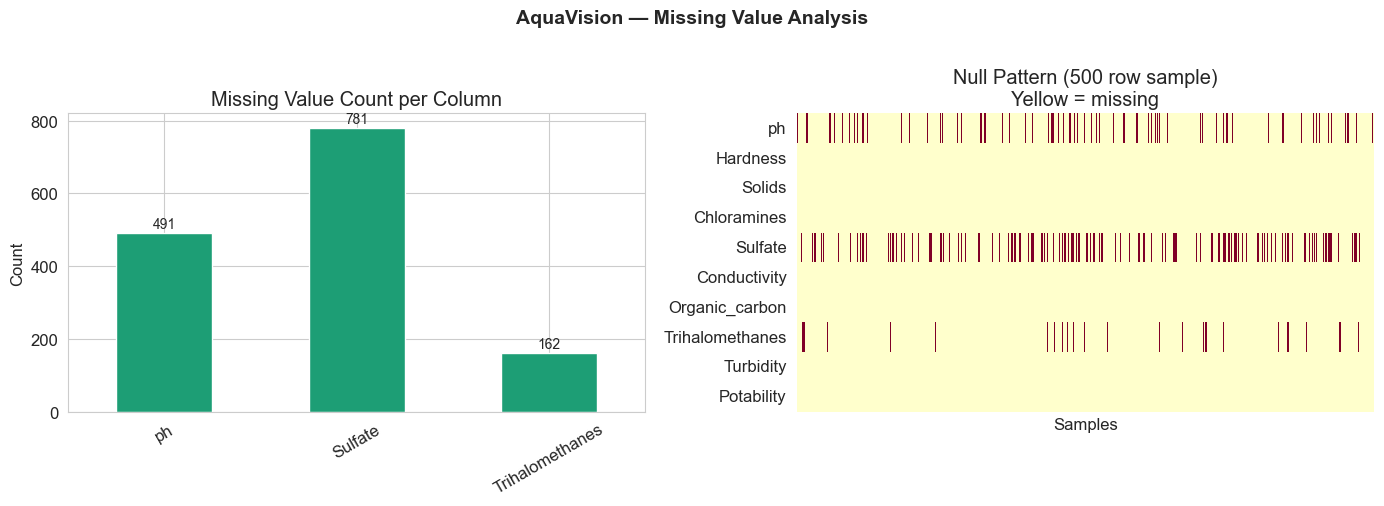

In [10]:
# ─────────────────────────────────────────────
# Section 6b: Missing value heatmap
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AquaVision — Missing Value Analysis', fontsize=14, fontweight='bold', y=1.01)

# Bar chart
cols_with_missing = missing_count[missing_count > 0]
if len(cols_with_missing) > 0:
    cols_with_missing.plot(kind='bar', ax=axes[0], color='#1d9e75', edgecolor='white')
    axes[0].set_title('Missing Value Count per Column')
    axes[0].set_ylabel('Count')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=30)
    for bar, val in zip(axes[0].patches, cols_with_missing):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     f'{val}', ha='center', va='bottom', fontsize=10)
else:
    axes[0].text(0.5, 0.5, 'No missing values!', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=14, color='green')
    axes[0].set_title('Missing Value Count per Column')

# Heatmap of nulls (sample 500 rows for readability)
sample_null = df.sample(min(500, len(df)), random_state=RANDOM_STATE).isnull()
sns.heatmap(sample_null.T, cmap='YlOrRd', cbar=False, ax=axes[1],
            yticklabels=True, xticklabels=False)
axes[1].set_title('Null Pattern (500 row sample)\nYellow = missing')
axes[1].set_xlabel('Samples')

plt.tight_layout()

# Save to reports
save_path = os.path.join(REPORTS_DIR, 'phase1_missing_values.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'📊 Chart saved to: {save_path}')
plt.show()

---

## 7. Data Types & Memory Usage

### 📖 Why this step?

Understanding data types helps us:
- Confirm all numeric columns are stored as `float64` or `int64` (not as `object`/string)
- Identify opportunities to **downcast** data types (e.g. `float64` → `float32`) to reduce memory usage — important when working with large datasets
- Spot incorrectly typed columns early

In [11]:
# ─────────────────────────────────────────────
# Section 7: Data Types & Memory
# ─────────────────────────────────────────────

print('═' * 60)
print('  DATA TYPES & MEMORY USAGE')
print('═' * 60)

memory_df = pd.DataFrame({
    'Data Type'   : df.dtypes,
    'Memory (KB)' : (df.memory_usage(deep=True)[1:] / 1024).round(3)
})
display(memory_df)

total_mem = df.memory_usage(deep=True).sum() / 1024
print(f'\n💾 Total memory usage: {total_mem:.2f} KB')

# Check target column distribution
print(f'\n🎯 Target column "{TARGET_COLUMN}" distribution:')
target_counts = df[TARGET_COLUMN].value_counts()
target_pct    = df[TARGET_COLUMN].value_counts(normalize=True) * 100
target_df = pd.DataFrame({'Count': target_counts, 'Percentage %': target_pct.round(2)})
target_df.index = ['Not Potable (0)', 'Potable (1)']
display(target_df)

════════════════════════════════════════════════════════════
  DATA TYPES & MEMORY USAGE
════════════════════════════════════════════════════════════


,Data Type,Memory (KB)
ph,float64,25.5940
Hardness,float64,25.5940
Solids,float64,25.5940
Chloramines,float64,25.5940
Sulfate,float64,25.5940
Conductivity,float64,25.5940
Organic_carbon,float64,25.5940
Trihalomethanes,float64,25.5940
Turbidity,float64,25.5940
Potability,int64,25.5940



💾 Total memory usage: 256.07 KB

🎯 Target column "Potability" distribution:


,Count,Percentage %
Not Potable (0),1998,60.9900
Potable (1),1278,39.0100


---

## 8. Key Observations & Next Steps

### 📖 Why this step?

Every professional notebook ends with a **summary of findings**. This forces clear thinking and creates a written record of decisions made. It also acts as a handoff document if another team member picks up the work.

---

### ✅ Key Observations from Phase 1

| # | Observation | Impact |
|---|---|---|
| 1 | Dataset has **3,276 rows × 10 columns** | Medium-sized, manageable |
| 2 | All features are **continuous numerical** (float64) | No encoding needed |
| 3 | **3 columns have missing values**: `ph`, `Sulfate`, `Trihalomethanes` | Must impute before modeling |
| 4 | Target column `Potability` is **imbalanced** (~61% not potable) | May need balancing in Phase 4 |
| 5 | No duplicate rows detected | Data integrity is good |

---

### 🔜 What Comes Next — Phase 2 (EDA)

Based on these findings, in `02_eda.ipynb` we will:

1. **Visualize distributions** of all 9 features (histograms + KDE plots)
2. **Detect outliers** using boxplots and IQR method
3. **Analyze correlations** between features using a heatmap
4. **Compare potable vs non-potable** samples across each feature
5. **Document skewness** values to decide on transformations

---

> 📌 **Notebook Status: Complete** — All raw data has been loaded, inspected, and documented. No transformations have been applied. The dataset is ready for exploratory analysis.

In [12]:
# ─────────────────────────────────────────────
# Phase 1 Complete — Save checkpoint
# ─────────────────────────────────────────────

print('=' * 60)
print('  ✅  PHASE 1 COMPLETE — Data Loading & Inspection')
print('=' * 60)
print(f'  Dataset shape   : {df.shape}')
print(f'  Missing values  : {df.isnull().sum().sum()} cells')
print(f'  Duplicate rows  : {df.duplicated().sum()}')
print(f'  All numeric     : {all(df.drop(columns=[TARGET_COLUMN]).dtypes == "float64")}')
print()
print('  Next → 02_eda.ipynb : Exploratory Data Analysis')
print('=' * 60)

  ✅  PHASE 1 COMPLETE — Data Loading & Inspection
  Dataset shape   : (3276, 10)
  Missing values  : 1434 cells
  Duplicate rows  : 0
  All numeric     : True

  Next → 02_eda.ipynb : Exploratory Data Analysis
